In [1]:
%matplotlib widget

In [2]:
import math
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import List, Tuple, Union
from dataclasses import dataclass
from scipy.spatial import distance
from scipy.linalg import block_diag
from numpy import dot
from numpy.linalg import norm

In [3]:
import os
import sys

sys.path.append('/home/morita/src/3D_Estimation/src')

from plot import *
from calculate import *
from optimization import *

## 線源と検出器の座標系

### 線源
空間 10 * 10 * 10 [m] \
線源位置 [4.0,4.0,0.0], 100 Gy\

### 検出器
高さ 0.5 [m]

### 遮蔽
鉛 \
1/10に減衰

In [4]:
# 線源
source_1 = [3.5, 3.5, 0.0, 100]
source_list = []
source_list.append(source_1)

In [5]:
# 部屋
x = 10
y = 10
z = 10

In [6]:
# グリッド 幅で指定
g = 1
q_max = 200
q_init = 1/q_max
q1 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 地面 z=0
q2 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 天井 z=10
q3 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面1 x=0
q4 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面2 y=0
q5 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面3 x=10
q6 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面4 y=10

In [7]:
# 各 qn の長さを確認
print(f"q1: {q1.shape}")
print(f"q2: {q2.shape}")
print(f"q3: {q3.shape}")
print(f"q4: {q4.shape}")
print(f"q5: {q5.shape}")
print(f"q6: {q6.shape}")

q1: (100, 1)
q2: (100, 1)
q3: (100, 1)
q4: (100, 1)
q5: (100, 1)
q6: (100, 1)


## 計測

In [8]:
def decide_measurement_points(x,y,r):
    m_p = []
    #z軸は固定
    m_p_c = []
    for i in range(x):
        for j in range(y):
            m_p_c.append([0.5+i,0.5+j,0.5])
    
    num_points = int(r * len(m_p_c))
    m_p = random.sample(m_p_c, num_points)
    return m_p

In [9]:
r = 1.0
m_p = decide_measurement_points(x,y,r)

In [10]:
# 一地点での計測回数
num_rotation = 8

### 遮蔽
1/8を覆う形

In [11]:
# 角度の8通りのシールド向きリスト
shield_orientations = [
    {'theta': (0, np.pi / 2), 'phi': (0, np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi / 2, np.pi)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (3 * np.pi / 2, 2 * np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (0, np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi / 2, np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (3 * np.pi / 2, 2 * np.pi)}
]


In [12]:
b_m = measurement_shield(m_p, source_list, shield_orientations)
print(len(b_m))
print(b_m)

800
[79.99999999999999, 79.99999999999999, 79.99999999999999, 79.99999999999999, 79.99999999999999, 79.99999999999999, 79.99999999999999, 79.99999999999999, 9.75609756097561, 9.75609756097561, 9.75609756097561, 9.75609756097561, 9.75609756097561, 9.75609756097561, 9.75609756097561, 9.75609756097561, 5.479452054794522, 5.479452054794522, 5.479452054794522, 5.479452054794522, 0.5576605460021375, 5.479452054794522, 5.479452054794522, 5.479452054794522, 2.484472049689441, 2.484472049689441, 2.484472049689441, 2.484472049689441, 2.484472049689441, 2.484472049689441, 2.484472049689441, 2.484472049689441, 7.547169811320755, 7.547169811320755, 7.547169811320755, 7.547169811320755, 0.7680984878897363, 7.547169811320755, 7.547169811320755, 7.547169811320755, 23.52941176470588, 23.52941176470588, 23.52941176470588, 23.52941176470588, 23.52941176470588, 2.394659991656237, 2.394659991656237, 23.52941176470588, 2.484472049689441, 2.484472049689441, 2.484472049689441, 2.484472049689441, 2.48447204968

### グリッド

In [13]:
# 例: グリッド生成時に g の値を指定（省略可）
ground_grid = create_grid('z', 0, g=1)    # 地面 z=0
ceiling_grid = create_grid('z', 10, g=1)  # 天井 z=10
side1_grid = create_grid('x', 0, g=1)     # 側面1 x=0
side2_grid = create_grid('y', 0, g=1)     # 側面2 y=0
side3_grid = create_grid('x', 10, g=1)    # 側面3 x=10
side4_grid = create_grid('y', 10, g=1)    # 側面4 y=10


# 結果をリストとして保存
all_grids = {
    "ground": ground_grid,
    "ceiling": ceiling_grid,
    "side1": side1_grid,
    "side2": side2_grid,
    "side3": side3_grid,
    "side4": side4_grid
}

# 各面のグリッドを出力
for surface, grid in all_grids.items():
    print(f"{surface} grid:")
    print(grid)
    print()


ground grid:
[[0.5, 0.5, 0], [1.5, 0.5, 0], [2.5, 0.5, 0], [3.5, 0.5, 0], [4.5, 0.5, 0], [5.5, 0.5, 0], [6.5, 0.5, 0], [7.5, 0.5, 0], [8.5, 0.5, 0], [9.5, 0.5, 0], [0.5, 1.5, 0], [1.5, 1.5, 0], [2.5, 1.5, 0], [3.5, 1.5, 0], [4.5, 1.5, 0], [5.5, 1.5, 0], [6.5, 1.5, 0], [7.5, 1.5, 0], [8.5, 1.5, 0], [9.5, 1.5, 0], [0.5, 2.5, 0], [1.5, 2.5, 0], [2.5, 2.5, 0], [3.5, 2.5, 0], [4.5, 2.5, 0], [5.5, 2.5, 0], [6.5, 2.5, 0], [7.5, 2.5, 0], [8.5, 2.5, 0], [9.5, 2.5, 0], [0.5, 3.5, 0], [1.5, 3.5, 0], [2.5, 3.5, 0], [3.5, 3.5, 0], [4.5, 3.5, 0], [5.5, 3.5, 0], [6.5, 3.5, 0], [7.5, 3.5, 0], [8.5, 3.5, 0], [9.5, 3.5, 0], [0.5, 4.5, 0], [1.5, 4.5, 0], [2.5, 4.5, 0], [3.5, 4.5, 0], [4.5, 4.5, 0], [5.5, 4.5, 0], [6.5, 4.5, 0], [7.5, 4.5, 0], [8.5, 4.5, 0], [9.5, 4.5, 0], [0.5, 5.5, 0], [1.5, 5.5, 0], [2.5, 5.5, 0], [3.5, 5.5, 0], [4.5, 5.5, 0], [5.5, 5.5, 0], [6.5, 5.5, 0], [7.5, 5.5, 0], [8.5, 5.5, 0], [9.5, 5.5, 0], [0.5, 6.5, 0], [1.5, 6.5, 0], [2.5, 6.5, 0], [3.5, 6.5, 0], [4.5, 6.5, 0], [5.5, 6.5, 

### A

In [14]:
# 各面のA行列の作成
A1 = create_A(10, 10, m_p, ground_grid, shield_orientations)  # 地面 z=0
A2 = create_A(10, 10, m_p, ceiling_grid, shield_orientations) # 天井 z=10
A3 = create_A(10, 10, m_p, side1_grid, shield_orientations)   # 側面1 x=0
A4= create_A(10, 10, m_p, side2_grid, shield_orientations)   # 側面2 y=0
A5= create_A(10, 10, m_p, side3_grid, shield_orientations)   # 側面3 x=10
A6 = create_A(10, 10, m_p, side4_grid, shield_orientations)   # 側面4 y=10

In [15]:
# 全体のA行列を結合
A = np.hstack((A1, A2, A3, A4, A5, A6))

print("Final A matrix:")
print(f"A: {A.shape}")

Final A matrix:
A: (800, 600)


In [16]:
q = np.vstack((q1, q2, q3, q4, q5, q6))
print(f"q: {q.shape}")
b = np.dot(A,q)
print(len(b))

q: (600, 1)
800


In [17]:
import numpy as np

# 線源の位置
source_1 = [4.0, 4.0, 0.0, 100]

# ground_grid の作成（地面 z=0）
ground_grid = create_grid('z', 0)  # 地面 z=0

# 結果の計算
nearest_point, nearest_index = find_nearest_grid(source_1, ground_grid)

print("Nearest grid point:", nearest_point)
print("Index of nearest grid point:", nearest_index)


Nearest grid point: [3.5, 3.5, 0]
Index of nearest grid point: 33


### 計算値が正しいかチェック

In [18]:
# 初期値
q_init_check = 0  # すべてのグリッドの初期値は0

# 各面のチェック用qベクトルを初期化
q_check1 = np.array([q_init_check] * (x * y)).reshape(x * y, 1)  # 地面 z=0
q_check2 = np.array([q_init_check] * (y * z)).reshape(y * z, 1)  # 天井 z=10
q_check3 = np.array([q_init_check] * (x * z)).reshape(x * z, 1)  # 側面1 x=0
q_check4 = np.array([q_init_check] * (y * z)).reshape(y * z, 1)  # 側面2 y=0
q_check5 = np.array([q_init_check] * (x * z)).reshape(x * z, 1)  # 側面3 x=10
q_check6 = np.array([q_init_check] * (x * y)).reshape(x * y, 1)  # 側面4 y=10

# グリッドリストとqリスト
grids = [ground_grid, side1_grid, side2_grid, side3_grid, side4_grid, ceiling_grid]
q_check_vectors = [q_check1, q_check2, q_check3, q_check4, q_check5, q_check6]

# 最も近いグリッドのインデックスを探し、強度を設定
def assign_source_intensity_for_check(source, grids, q_check_vectors):
    source_position = source[:3]
    intensity = source[3]
    
    nearest_grid_index = -1
    nearest_q_vector = None
    min_distance = float('inf')
    
    # 最も近いグリッドとそのインデックスを見つける
    for grid, q_check_vector in zip(grids, q_check_vectors):
        for index, point in enumerate(grid):
            distance = calculate_distance(source_position[0], source_position[1], source_position[2], point[0], point[1], point[2])
            if distance < min_distance:
                min_distance = distance
                nearest_grid_index = index
                nearest_q_vector = q_check_vector

    # 最も近いqベクトルのみに強度を設定し、他は0のまま
    if nearest_q_vector is not None and nearest_grid_index != -1:
        nearest_q_vector.fill(0)  # すべての値を0にリセット
        nearest_q_vector[nearest_grid_index] = intensity

# 線源の強度を適用
assign_source_intensity_for_check(source_1, grids, q_check_vectors)

# 結果を表示
print("q_check1 (ground grid) with assigned source intensity:\n", q_check1)
print("q_check2 (side1 grid) with assigned source intensity:\n", q_check2)
print("q_check3 (side2 grid) with assigned source intensity:\n", q_check3)
print("q_check4 (side3 grid) with assigned source intensity:\n", q_check4)
print("q_check5 (side4 grid) with assigned source intensity:\n", q_check5)
print("q_check6 (ceiling grid) with assigned source intensity:\n", q_check6)


q_check1 (ground grid) with assigned source intensity:
 [[  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [100]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]]
q_check2 (side1 grid) with assigned source intensity:
 [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0

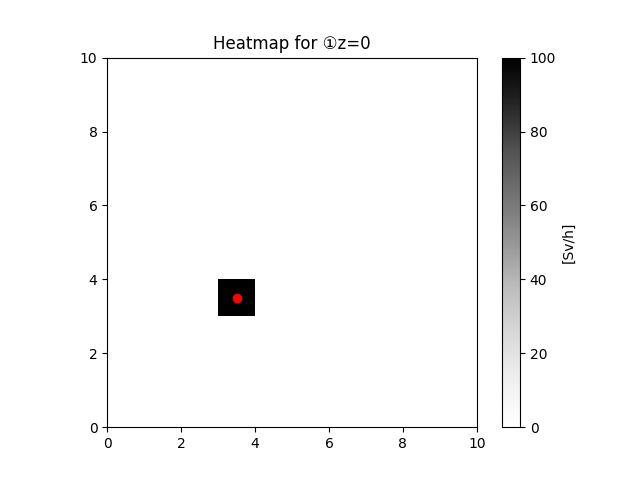

In [19]:
plot_heatmap(q_check1,  (x, y), [0, x, 0, y], 'Heatmap for ①z=0',  sources=source_list)

In [20]:
q_check = np.vstack((q_check1, q_check2, q_check3, q_check4, q_check5, q_check6))
print(f"q_check: {q_check.shape}")
b_check = np.dot(A,q_check)
print(len(b_check))
print(b_check)

q_check: (600, 1)
800
[[8.00000000e+01]
 [8.00000000e+01]
 [8.00000000e+01]
 [8.00000000e+01]
 [8.00000000e+01]
 [8.00000000e+01]
 [8.00000000e+01]
 [8.00000000e+01]
 [9.75609756e+00]
 [9.75609756e+00]
 [9.75609756e+00]
 [9.75609756e+00]
 [9.75609756e+00]
 [9.75609756e+00]
 [9.75609756e+00]
 [9.75609756e+00]
 [5.47945205e+00]
 [5.47945205e+00]
 [5.47945205e+00]
 [5.47945205e+00]
 [3.05567422e-02]
 [5.47945205e+00]
 [5.47945205e+00]
 [5.47945205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [7.54716981e+00]
 [7.54716981e+00]
 [7.54716981e+00]
 [7.54716981e+00]
 [5.79696972e-02]
 [7.54716981e+00]
 [7.54716981e+00]
 [7.54716981e+00]
 [2.35294118e+01]
 [2.35294118e+01]
 [2.35294118e+01]
 [2.35294118e+01]
 [2.35294118e+01]
 [5.63449410e-01]
 [5.63449410e-01]
 [2.35294118e+01]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48447205e+00]
 [2.48

In [21]:
# コサイン類似度の計算
cosine_similarity = dot(b_check.flatten(), b_m) / (norm(b_check) * norm(b_m))
print("Cosine Similarity:", cosine_similarity)

Cosine Similarity: 0.9947832391115661


## MLE
### 最適化

In [22]:
b_m_s = np.array(b_m)

In [23]:
init_score = score_func(A,b_m_s,q)
print(f'initial score{init_score}')

initial score-19381881.14803555


In [24]:
q_optimized = Adam(A, b_m_s, q, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, max_iter=20000)

In [25]:
q_shapes = [
    (x * y, 1),  # 地面 z=0 に対応
    (x * y, 1),  # 天井 z=10 に対応
    (y * z, 1),  # 側面1 x=0 に対応
    (x * z, 1),  # 側面2 y=0 に対応
    (y * z, 1),  # 側面3 x=10 に対応
    (x * z, 1)   # 側面4 y=10 に対応
]
restored_qs = restore_q(q_optimized, q_shapes)

In [26]:
# 各qの最大値と最小値を求める
all_q_values = np.concatenate([q.flatten() for q in restored_qs])
vmin, vmax = all_q_values.min(), all_q_values.max()

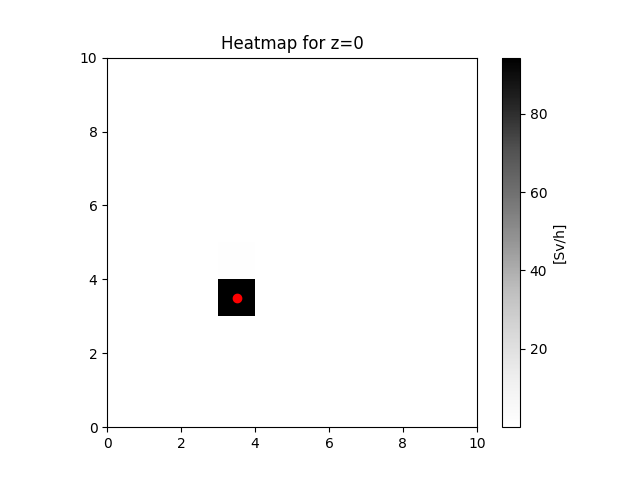

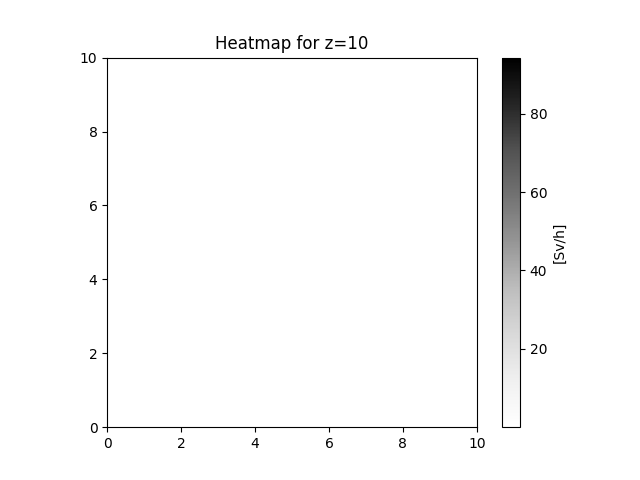

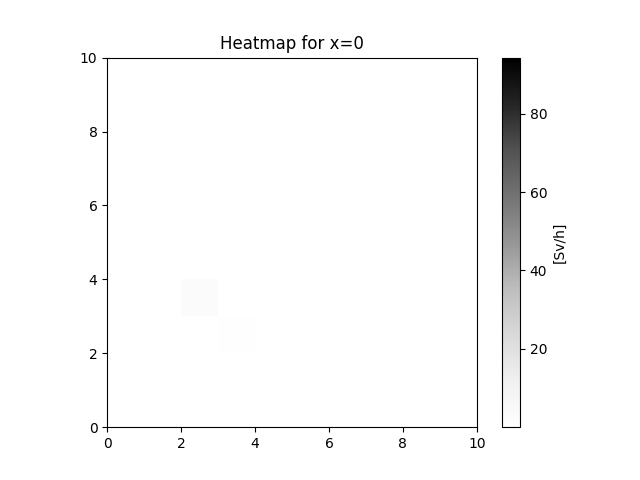

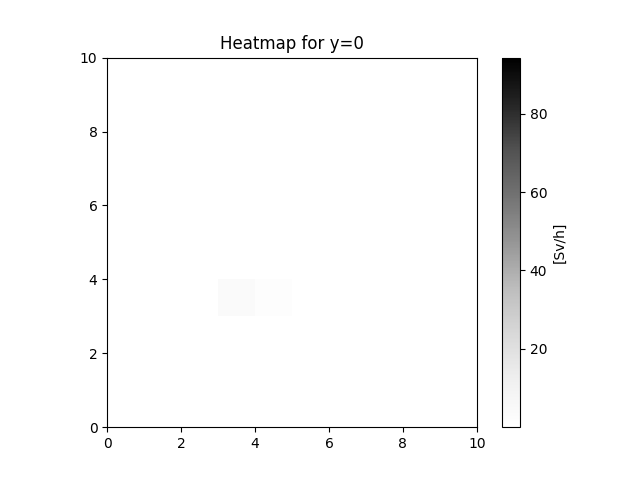

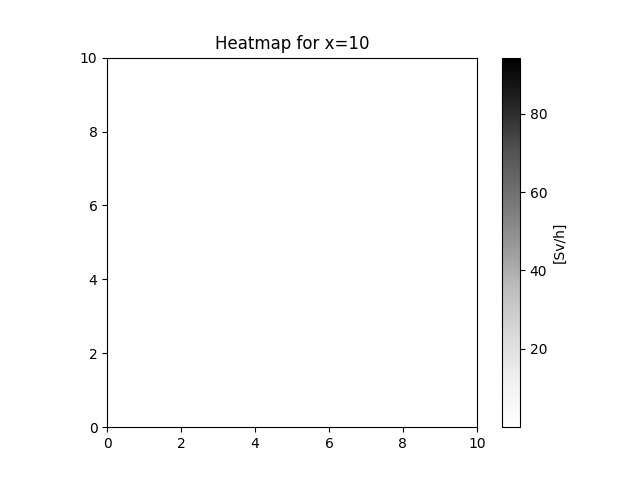

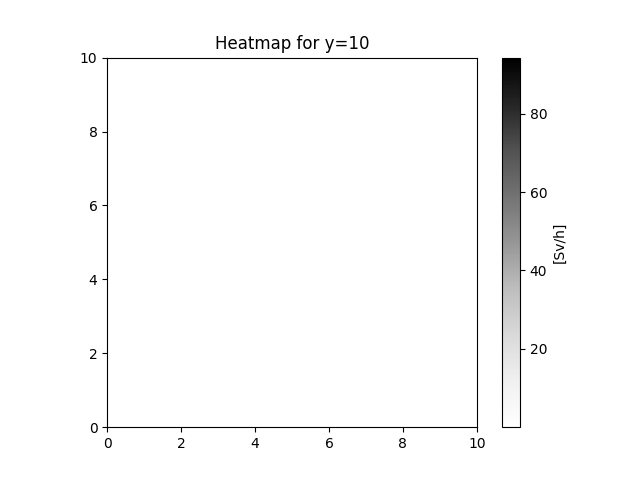

In [27]:
# 地面 z=0
plot_heatmap(restored_qs[0].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=0', sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin, vmax=vmax)

# 天井 z=10
plot_heatmap(restored_qs[1].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=10', sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin, vmax=vmax)

# 側面1 x=0
plot_heatmap(restored_qs[2].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=0', sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin, vmax=vmax)

# 側面2 y=0
plot_heatmap(restored_qs[3].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=0', sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin, vmax=vmax)

# 側面3 x=10
plot_heatmap(restored_qs[4].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=10', sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin, vmax=vmax)

# 側面4 y=10
plot_heatmap(restored_qs[5].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=10', sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin, vmax=vmax)


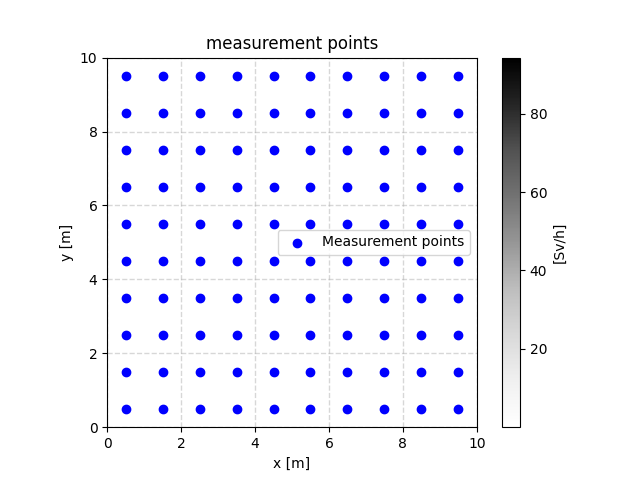

In [28]:
plot_measurement_points(m_p, source_list, "measurement points", x, y)

In [29]:
def plot_heatmap_result_no_colorbar(q, shape, extent, sources=None, vmin=None, vmax=None):
    q_grid = q.reshape(shape)
    plt.figure()
    plt.imshow(q_grid, origin='lower', cmap='Greys', extent=extent, vmin=vmin, vmax=vmax)
    
    # 軸とカラーバーを表示しない
    plt.axis('off')
    
    # 放射線源を表示するオプション
    if sources:
        for source in sources:
            plt.scatter(source[0], source[1], color='red')
    
    plt.show()

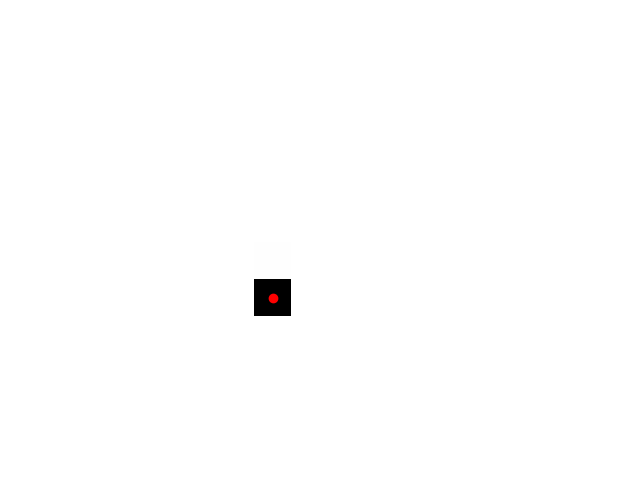

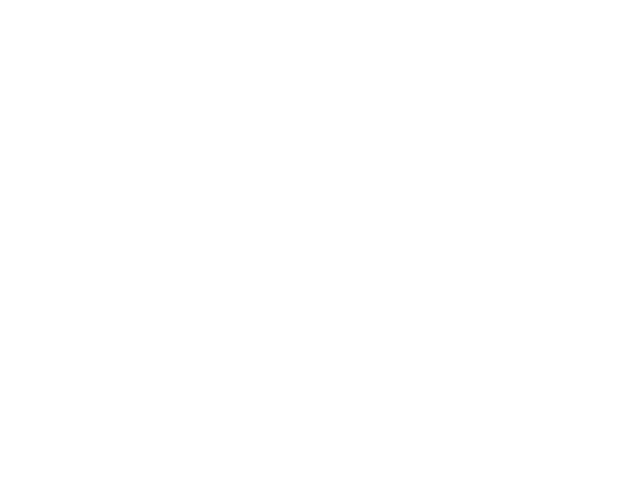

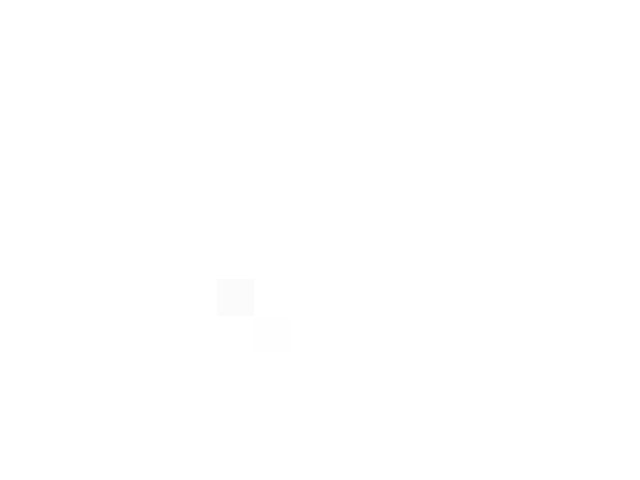

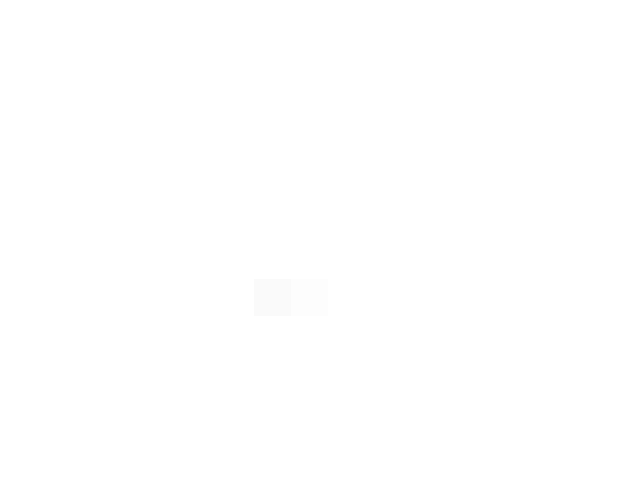

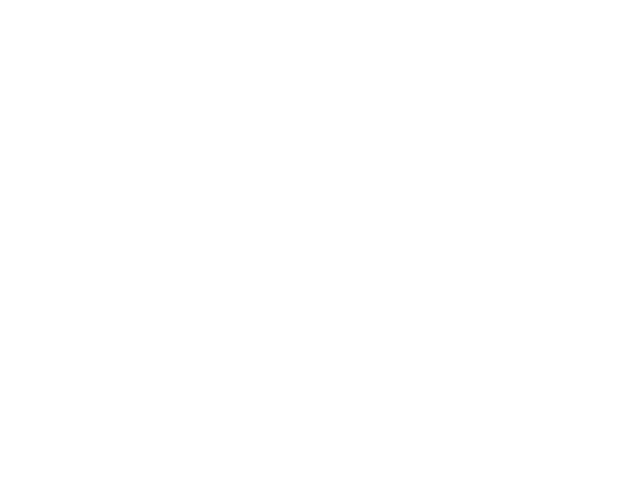

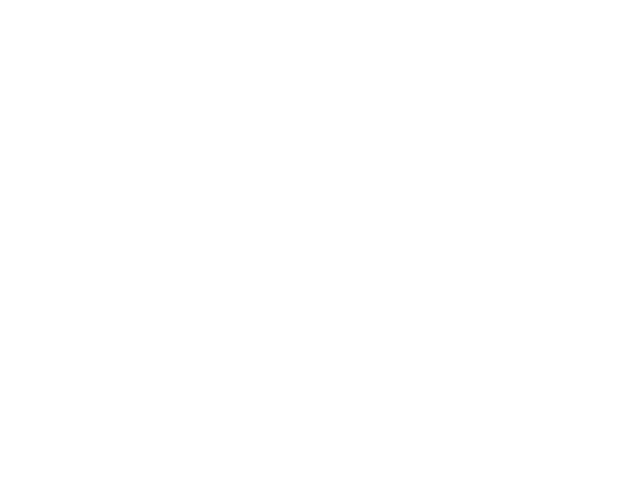

In [30]:
# 地面 z=0
plot_heatmap_result_no_colorbar(restored_qs[0].reshape((x, y)), (x, y), [0, x, 0, y], sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin, vmax=vmax)

# 天井 z=10
plot_heatmap_result_no_colorbar(restored_qs[1].reshape((x, y)), (x, y), [0, x, 0, y], sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin, vmax=vmax)

# 側面1 x=0
plot_heatmap_result_no_colorbar(restored_qs[2].reshape((y, z)), (y, z), [0, y, 0, z], sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin, vmax=vmax)

# 側面2 y=0
plot_heatmap_result_no_colorbar(restored_qs[3].reshape((x, z)), (x, z), [0, x, 0, z], sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin, vmax=vmax)

# 側面3 x=10
plot_heatmap_result_no_colorbar(restored_qs[4].reshape((y, z)), (y, z), [0, y, 0, z], sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin, vmax=vmax)

# 側面4 y=10
plot_heatmap_result_no_colorbar(restored_qs[5].reshape((x, z)), (x, z), [0, x, 0, z], sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin, vmax=vmax)

In [33]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_3d_heatmap_cube(qs, x, y, z, sources=None, vmin=None, vmax=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # 色範囲の設定
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    
    # 地面 z=0
    ground = qs[0].reshape((x, y))
    X, Y = np.meshgrid(np.linspace(0, x, x), np.linspace(0, y, y))
    ax.plot_surface(X, Y, np.zeros_like(X), facecolors=plt.cm.Greys(norm(ground)), shade=False)

    # 天井 z=10
    ceiling = qs[1].reshape((x, y))
    ax.plot_surface(X, Y, np.full_like(X, z), facecolors=plt.cm.Greys(norm(ceiling)), shade=False)

    # 側面1 x=0
    side1 = qs[2].reshape((y, z))
    Y, Z = np.meshgrid(np.linspace(0, y, y), np.linspace(0, z, z))
    ax.plot_surface(np.zeros_like(Y), Y, Z, facecolors=plt.cm.Greys(norm(side1)), shade=False)

    # 側面2 y=0
    side2 = qs[3].reshape((x, z))
    X, Z = np.meshgrid(np.linspace(0, x, x), np.linspace(0, z, z))
    ax.plot_surface(X, np.zeros_like(X), Z, facecolors=plt.cm.Greys(norm(side2)), shade=False)

    # 側面3 x=10
    side3 = qs[4].reshape((y, z))
    ax.plot_surface(np.full_like(Y, x), Y, Z, facecolors=plt.cm.Greys(norm(side3)), shade=False)

    # 側面4 y=10
    side4 = qs[5].reshape((x, z))
    ax.plot_surface(X, np.full_like(X, y), Z, facecolors=plt.cm.Greys(norm(side4)), shade=False)

    # 放射線源の位置を3D空間内にプロット（赤色の点）
    if sources:
        for source in sources:
            ax.scatter(source[0], source[1], source[2], color='red', s=50)

    # 軸のラベル
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # カラーバーの範囲のみ指定（表示しない）
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='Greys'), ax=ax, shrink=0.5, aspect=5, label='[Bq]')
    plt.show()


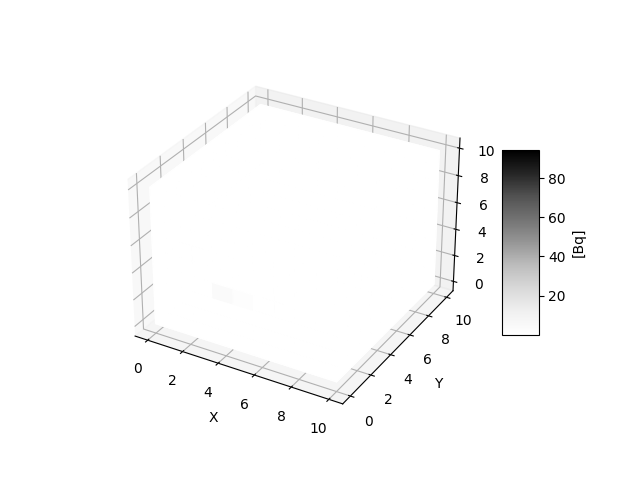

In [34]:
# 各面のデータと最小・最大の放射線量を設定
qs = restored_qs
vmin, vmax = all_q_values.min(), all_q_values.max()  # 先に計算された vmin, vmax

plot_3d_heatmap_cube(qs, x, y, z, sources=source_list, vmin=vmin, vmax=vmax)

